# Physical 3D CLN including air and a defined return

A conductor in a **perfectly conducting enclosure (coaxial-type return)** is driven by a one-volt generalized circuit port. The top contact is bonded to the return; the bottom electrode is insulated and driven by an ideal lumped source. Connecting both contacts directly to the shell would short this port. Its voltage is power-conjugate to current, not an electric-field path integral through arbitrary air paths.

This linear magnetoquasistatic device excludes capacitance, displacement current, feedthrough/lead details, finite shell loss and open-space fields. Tangential A is zero on the enclosure, with zero initially trapped flux; it is continuous and unconstrained at the conductor/air interface. Air conductivity is **exactly zero**. A–phi is primary, A–T independently discretizes conductor currents while sharing the global magnetic solver. T–Omega is excluded: a single-valued air scalar cannot carry the linked current circulation without a cut or cohomology source field.

Design review is accepted; numerical candidate review is pending. Stage A remains [the separate interior-boundary experiment](12_general_3d_cln.ipynb).

In [1]:
%matplotlib inline
import json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
DATA=Path('data') if Path('data/general_3d_air.json').exists() else Path('docs/data')
study=json.loads((DATA/'general_3d_air.json').read_text())
assert study['complete']
cases=study['cases'];tags={c['tag']:c for c in cases}
print(study['scope']);print(study['runtime']);print(study['solver'])
print('Native meshes:',len(cases),'form/shift runs:',sum(len(c['runs'])+len(c['A_T_runs']) for c in cases))
environment=json.loads((DATA/'general_3d_air_environment.json').read_text())
print(environment['runtime'])


Conductor in a perfectly conducting enclosure with ideal source-break port; sigma_air=0 exactly; no capacitance or return-wall loss
{'python': '3.12.10', 'ngsolve': '6.2.2607', 'netgen': '6.2.2607', 'float64_epsilon': 2.220446049250313e-16, 'longdouble_epsilon': 2.220446049250313e-16}
Explicit equilibrated sparse LU with three residual corrections of the same factors; NumPy longdouble is platform-dependent (float64 on Windows); no reorthogonalization
Native meshes: 11 form/shift runs: 44
{'python': '3.12.10', 'numpy': '2.5.2', 'scipy': '1.17.1', 'ngsolve': '6.2.2607', 'netgen': '6.2.2607', 'mpmath': '1.3.0', 'platform': 'Windows', 'architecture': 'AMD64', 'declared_ngsolve_threads': 4, 'float64_epsilon': 2.220446049250313e-16, 'longdouble_epsilon': 2.220446049250313e-16}


## Global magnetic field, conductor-only continuity and gauge

The conductor lift solves phi0=1 at the entering terminal and 0 at the exit. Let e0=-grad(phi0). All conductivity blocks M,S,C,f and Joule norms are integrated only in the conductor. K is the curl-curl operator over conductor **and air**, and K=K_D+K_air.

$$ (K+sM)a+C^T\chi=f,\qquad sCa+S\chi=0,\qquad I=G_0-sf^Ta,\quad Z=1/I. $$

The complete global gradient map includes air-supported gradients. The declared alpha GG^T gauge term is not an artificial air conductivity or L2 physical regularization. The conductor scalar uses the global H1 numbering with only conductor-active, homogeneous-terminal degrees retained. P is the explicit scalar restriction; KG=0, MG=C^TP, CG=SP and f^TG=0 are checked. Fields and port are checked under gauge-weight changes. Sparse LU uses three residual corrections of the same factors, not mode reorthogonalization.

This reproduction uses the **same explicit tetrahedron integration rule** in every block and energy integral; a common relative bonus alone need not give identical rules for mixed spaces. The accepted cohorts use quadratic geometry and sample positive Jacobian determinants. Geometry error is separately budgeted.
NumPy longdouble is platform-dependent and equals float64 in the recorded Windows environment; both epsilon values are stored. No extended-precision solve is claimed.

Coaxial meshes use curvature-safety 3 to resolve the circular mapping. The coarser default mapping failed the deep-element quadrature gate and is not part of the completed evidence. The recorded coax grid uses coarse/refined linear elements and coarse quadratic elements, all with A–phi and A–T. A refined quadratic coax is not included in this feasible grid; the observed refined linear case already needed about 17 minutes and about 9 GiB at an intermediate memory sample. The full notched conductor/air refinement families are retained.


In [2]:
print('tag | p | conductor/air elements | actual max conductor/air chord [mm] | seconds')
for c in cases:
    m=c['mesh'];print(c['tag'],m['order'],m['region_element_counts'],
        {k:1e3*v for k,v in m['region_max_chord_m'].items()},round(c['seconds'],2))
print('Maximum block-identity defect:',max(v for c in cases for v in c['identities'].values()))
print('Original full-equation residual:',max(c['original_residual_max'] for c in cases))

tag | p | conductor/air elements | actual max conductor/air chord [mm] | seconds
coax_p1_base 1 {'conductor': 878, 'air': 2445} {'conductor': 4.391731788958955, 'air': 7.957985995911875} 91.91
coax_p1_D1 1 {'conductor': 3722, 'air': 2458} {'conductor': 3.1692886166936756, 'air': 7.957985995911875} 1007.9
coax_p2_base 2 {'conductor': 878, 'air': 2445} {'conductor': 4.391731788958955, 'air': 7.957985995911875} 1062.06
notched_p1_base 1 {'conductor': 136, 'air': 559} {'conductor': 12.0, 'air': 12.0} 4.27
notched_p1_D1 1 {'conductor': 482, 'air': 662} {'conductor': 10.034662148993577, 'air': 11.242471574743682} 14.38
notched_p1_D2 1 {'conductor': 1516, 'air': 1315} {'conductor': 8.34374349770866, 'air': 9.58253600929301} 94.46
notched_p1_A1 1 {'conductor': 309, 'air': 2044} {'conductor': 11.296308919764018, 'air': 10.965856099730654} 24.37
notched_p1_A2 1 {'conductor': 967, 'air': 6449} {'conductor': 8.18817158959643, 'air': 8.07757166279356} 107.12
notched_p2_base 2 {'conductor': 136, 'ai

## Energy-normalized Type2 field recursion

For admissible conductor currents, r(u,v)=integral_D u.v/sigma, while ell(u,v)=ell_D+ell_air integrates B[u].B[v]/mu over the entire enclosed device. The inductive forcing A[x] is **restricted to the conductor** before loading the response; the global magnetic solve reconstructs its air field. No air current is added.

$$ j_0=F_{s_0}(e_0),\quad \widehat R_{2k}=\frac1{r(j_k,j_k)+s_0\ell(j_k,j_k)}, $$
$$ x_k=x_{k-1}+\widehat R_{2k}j_k,\quad L_{2k+1}=\ell(x_k,x_k),\quad j_{k+1}=j_k-F_{s_0}(A[x_k]|_D)/L_{2k+1}. $$

Eight elements terminate on the last qL branch, q=s-s0. Electric modes are orthogonal in r+s0 ell; cumulative magnetic modes are orthogonal in ell. The physical projected pencil is R_phys+s L_phys. Positivity of shifted q coefficients alone is not a passivity proof. The real positive expansion point 2*pi*10 kHz is not an imaginary frequency. Adding external series inductance changes **every Type2 element**, not only L1.
Full and reduced Taylor coefficients are computed directly with a unit-current, work-conjugate voltage constraint. Inverting a voltage-driven admittance series caused cancellation in the tiny high-order impedance coefficients when air series inductance dominated. The independent dense checker constructs the current constraint from the original matrices; the coefficient gates remain unchanged. This affects the verification path, not the physical field recurrence.


In [3]:
runs=[r for c in cases for r in c['runs']+c['A_T_runs']]
print('Orthogonality maxima:',max(r['electric_orth'] for r in runs),max(r['magnetic_orth'] for r in runs))
print('Ladder/Galerkin maximum:',max(f['ladder_galerkin_error'] for r in runs for f in r['frequency']))
errors=[]
for r in runs:
    f=np.array(r['moments']['full_Z_coefficients'])[:-1]
    g=np.array(r['moments']['galerkin_Z_coefficients'])[:-1]
    errors.append(np.max(abs(g-f)/np.maximum(abs(f),1e-14*abs(f).max())))
print('Contact q0..q7 maximum per coefficient:',max(errors))
print('Coarse original matrices exported for independent recursion/contact checks.')

Orthogonality maxima: 3.111206191130932e-10 2.702949210342808e-09
Ladder/Galerkin maximum: 5.586585335263404e-13
Contact q0..q7 maximum per coefficient: 1.0275506822739728e-12
Coarse original matrices exported for independent recursion/contact checks.


## Exact coax oracle before the non-symmetric example

For radius a=5 mm, shell radius b=15 mm and height h=15 mm, the endplate boundary admits the axially invariant coax solution. With kappa^2=mu sigma s,

$$Z_{\rm int}(s)=\frac{h\kappa}{2\pi a\sigma}\frac{I_0(\kappa a)}{I_1(\kappa a)},\qquad Z(s)=Z_{\rm int}(s)+s\frac{\mu h}{2\pi}\log(b/a).$$

At DC, Rdc=h/(sigma*pi*a^2), L_D=mu*h/(8*pi)=0.75 nH, and L_air=3.29584 nH, giving L1=4.04584 nH. This is an exact series-impedance oracle for the stated ideal MQS boundary problem, not a full-wave transmission-line input impedance or open finite wire.

[Wolfram derivation](../mathematica/derive_coax_enclosure.wls) and the independent [high-precision Python oracle](../validation/cln3d/coax_oracle.py) derive Taylor fractions. CI uses a separate convergent hypergeometric series for frequency values. The finest cohort must pass 1% full-Z on its explicitly screen-passing sampled band and 1% on **each** DC energy part. Deeper elements are conditioning-sensitive and are reported rather than assumed accurate.
At each screen-passing frequency of the accepted quadratic coax, the unit-current Joule loss and both magnetic-energy parts must also agree with independently integrated Bessel fields within 1%. This prevents external inductance from hiding an inaccurate conductor field behind a small total-Z error. Higher-frequency energy errors are reported without being counted as resolved accuracy.


In [4]:
for tag in ['coax_p1_base','coax_p1_D1','coax_p2_base']:
    c=tags[tag];m=c['mesh'];r=c['runs'][0]
    print(tag,'DC conductor/air L errors',c['oracle_dc_region_relative_errors'])
    print('geometry volume/area/perimeter errors:',[m[k] for k in ['conductor_volume_error','contact_area_error','conductor_perimeter_error']])
    print('Enclosure total-volume error:',abs((m['conductor_volume']+m['air_volume'])/(math.pi*m['enclosure']**2*.015)-1))
    print('frequency, exact full-Z error, skin screen:',[(f['hz'],f['full_oracle_error'],f['mesh_resolution_screen']) for f in r['frequency']])
    print('DC Ampere diagnostics:',c['DC_ampere']['loops'])
fine=tags['coax_p2_base']
for r in fine['runs']:
    print('s0',r['s0'],'Rhat:',r['Rhat'],'exact:',r['oracle_Rhat'])
    print('Inductances:',r['L'],'exact:',r['oracle_L'])
field_oracle=json.loads((DATA/'general_3d_air_fields.json').read_text())
for fe, exact in zip(fine['runs'][0]['frequency'],field_oracle['cases']):
    current=abs(1/complex(*fe['full_Z']))
    regional=np.array(fe['magnetic_regions'])/current**2
    target=np.array([exact['unit_current_magnetic_conductor'],exact['unit_current_magnetic_air']])
    print('Unit-current Bessel energy-part relative errors',fe['hz'],abs(regional/target-1),'skin screen',fe['mesh_resolution_screen'],'Joule error',abs(fe['full_loss']/current**2/exact['unit_current_joule']-1))

print('Coax A-T comparisons (shared DC lift and magnetic operator):')
for tag in ['coax_p1_base','coax_p1_D1','coax_p2_base']:
    c=tags[tag]
    for ap,at in zip(c['runs'],c['A_T_runs']):
        print(tag,'s0',ap['s0'],'A-T Rhat',at['Rhat'],'A-T L',at['L'])
        print('Element relative gaps',abs(np.array(at['Rhat'])/ap['Rhat']-1),abs(np.array(at['L'])/ap['L']-1))
        print('Full Z gaps',[(a['hz'],abs(complex(*t['full_Z'])/complex(*a['full_Z'])-1)) for a,t in zip(ap['frequency'],at['frequency'])])


coax_p1_base DC conductor/air L errors [0.03176981369882603, 0.011252675397047884]
geometry volume/area/perimeter errors: [4.860403072082242e-05, 7.830622502458251e-05, 2.419369056838594e-05]
Enclosure total-volume error: 6.0175114605098834e-05
frequency, exact full-Z error, skin screen: [(1000.0, 0.001986267822724657, True), (10000.0, 0.011773519745509749, False), (100000.0, 0.018449102564200855, False), (1000000.0, 0.03510332725689014, False)]
DC Ampere diagnostics: [{'loop_fraction': 0.72, 'H_circulation': 4971.258991010052, 'relative_current_defect': 0.05051332025241739}, {'loop_fraction': 0.9, 'H_circulation': 5508.211255990532, 'relative_current_defect': 0.052041993035670586}]
coax_p1_D1 DC conductor/air L errors [0.01417000582147987, 0.01132754869194863]
geometry volume/area/perimeter errors: [4.8281411693773535e-05, 7.830622502436047e-05, 2.4033659713262878e-05]
Enclosure total-volume error: 6.01751146054319e-05
frequency, exact full-Z error, skin screen: [(1000.0, 0.0015643436

## Magnetic energy outside the conductor

The notched block retains the stage-A shape and non-trivial scalar potential. The enclosure half-width is a physical device parameter. The first cumulative magnetic mode carries unit current; its split therefore directly shows conductor and air contributions to L1, including at positive real s0. These are energy forms without the time-average one-half factor; complex power uses the same convention.
Near-wall return-current sampling is reported with both the mean and the maximum over 16 heights. The base quadratic coax reaches about 1.12% maximum defect at a 0.1% inward offset, so a separate air-refined **DC-only** field diagnostic is included. It is not counted as another dynamic CLN cohort or a higher-frequency accuracy result.


In [5]:
for c in cases:
    if c['mesh']['geometry']!='notched':continue
    print(c['tag'],'phi departure:',c['mesh']['phi_departure_l2_relative'])
    for r in c['runs']:
        parts=np.array(r['energy'][0]['cumulative_region_integrals'])
        print('s0',r['s0'],'L1 conductor/air [nH]:',1e9*parts,'air share:',parts[1]/parts.sum())
print('Same-mesh Stage-A clamp control:',study['stage_A_control'])
shell=json.loads((DATA/'general_3d_air_shell.json').read_text())
for c in shell['cases']:print('Near-wall return current diagnostic:',c['tag'],c['relative_mean_balance'],c['relative_max_balance'])

notched_p1_base phi departure: 0.07144060634592608
s0 0.0 L1 conductor/air [nH]: [0.64808135 2.00755066] air share: 0.7559596567391754
s0 62831.853071795864 L1 conductor/air [nH]: [0.33956461 1.95180815] air share: 0.8518073461533283
notched_p1_D1 phi departure: 0.07235551564186918
s0 0.0 L1 conductor/air [nH]: [0.67613391 2.01393074] air share: 0.7486551459793865
s0 62831.853071795864 L1 conductor/air [nH]: [0.36808499 1.96438121] air share: 0.8421906432347658
notched_p1_D2 phi departure: 0.07256311442231465
s0 0.0 L1 conductor/air [nH]: [0.69340481 2.02051847] air share: 0.7445009553617323
s0 62831.853071795864 L1 conductor/air [nH]: [0.38663671 1.97511161] air share: 0.8362921642344695
notched_p1_A1 phi departure: 0.07197088617993239
s0 0.0 L1 conductor/air [nH]: [0.66510341 2.03391771] air share: 0.7535760631991588
s0 62831.853071795864 L1 conductor/air [nH]: [0.3571922  1.98512576] air share: 0.8475048177388848
notched_p1_A2 phi departure: 0.07261493696419796
s0 0.0 L1 conductor/a

## Refinement in each region and enclosure-size sensitivity

Region-marked bisection starts from one conformal mesh. D1/D2 mark conductor elements; A1/A2 mark air elements. Conformity closure may also refine the other material: both counts and actual chord sizes are reported. These are not perfectly isolated meshes or asymptotic rates. The p1/p2 base pair uses identical geometry and tetrahedra.

Changing b from 15 to 20 to 30 mm changes the return device. It is **not** convergence of an open boundary. A circular effective-area logarithm gives only a rough trend estimate for the square/non-symmetric geometry; it is not an analytic oracle.

In [6]:
base=tags['notched_p1_base']
for tag in ['notched_p1_base','notched_p1_D1','notched_p1_D2','notched_p1_A1','notched_p1_A2','notched_p2_base']:
    c=tags[tag];r=c['runs'][0]
    print(tag,c['mesh']['region_element_counts'],'L1[nH]',r['L'][0]*1e9,
          'full Z relative change vs base',[abs(complex(*f['full_Z'])/complex(*g['full_Z'])-1) for f,g in zip(r['frequency'],base['runs'][0]['frequency'])])
mu=4e-7*np.pi;h=.015;aeff=np.sqrt(base['mesh']['conductor_volume']/(h*np.pi))
for tag in ['notched_b15','notched_p1_base','notched_b30']:
    c=tags[tag];b=c['mesh']['enclosure'];beff=2*b/np.sqrt(np.pi)
    print(tag,'b[mm]',1e3*b,'L1[nH]',c['runs'][0]['L'][0]*1e9,
          'rough circular L_air[nH]',1e9*mu*h*np.log(beff/aeff)/(2*np.pi),
          'Z(real s0)',c['runs'][1]['moments']['full_Z_coefficients'][0])

notched_p1_base {'conductor': 136, 'air': 559} L1[nH] 2.655632012773965 full Z relative change vs base [0.0, 0.0, 0.0, 0.0]
notched_p1_D1 {'conductor': 482, 'air': 662} L1[nH] 2.69006464397785 full Z relative change vs base [0.005106211237312836, 0.009938579615745674, 0.03244358801883883, 0.016799451317000003]
notched_p1_D2 {'conductor': 1516, 'air': 1315} L1[nH] 2.713923279611971 full Z relative change vs base [0.008424216566516207, 0.017963919564917528, 0.05218193247675151, 0.02841347099163715]
notched_p1_A1 {'conductor': 309, 'air': 2044} L1[nH] 2.699021125833135 full Z relative change vs base [0.006093720308223971, 0.014308730914968384, 0.03693847418601256, 0.02694366387710092]
notched_p1_A2 {'conductor': 967, 'air': 6449} L1[nH] 2.72940150115891 full Z relative change vs base [0.010422593816532866, 0.024250530226887126, 0.062458396827451204, 0.04785716530955907]
notched_p2_base {'conductor': 136, 'air': 559} L1[nH] 2.7618036136672313 full Z relative change vs base [0.0147400143902

## A–T comparison and reduction error

A–T uses J=I*j_dc+curl T, a free scalar port current, side-only tangential T constraints including contact rims, and the same global A operator. It shares the DC lift and magnetic boundary; it is an independent **current discretization**, not an independent exterior solver. Shared first elements are controls. Full response gaps, all eight element gaps and their mesh dependence are reported; no deep-element cross-validation is presumed.

notched_p1_base s0 0.0 R0 L1 R2 L3 R4 L5 R6 L7 gaps[%]: [0.00000000e+00 2.44249065e-13 5.20460027e+01 2.34321023e+01
 1.60843372e+02 1.24174478e+02 4.75366709e+01 1.81568367e+01]
full Z gaps: [0.0015101979965491492, 0.033758500444767456, 0.07612874791773068, 0.07049284701409968]
notched_p1_base s0 62831.853071795864 R0 L1 R2 L3 R4 L5 R6 L7 gaps[%]: [  2.03448087   4.3291819   35.48330782  21.73541626 120.38491466
  24.79839394  46.32910202  53.98530348]
full Z gaps: [0.0015101979965491492, 0.033758500444767456, 0.07612874791773068, 0.07049284701409968]
notched_p1_D1 s0 0.0 R0 L1 R2 L3 R4 L5 R6 L7 gaps[%]: [0.00000000e+00 7.21644966e-13 2.64522937e+01 1.72137738e+01
 6.63060042e+01 4.56473106e+01 5.96169379e+00 1.78789864e+01]
full Z gaps: [0.0009369907238019249, 0.019921843290176627, 0.05064372730333052, 0.05283412514978756]
notched_p1_D1 s0 62831.853071795864 R0 L1 R2 L3 R4 L5 R6 L7 gaps[%]: [ 1.24133211  2.64361083 22.16925188 19.4896978  46.12639082  4.38797183
 15.92078304  7.16511

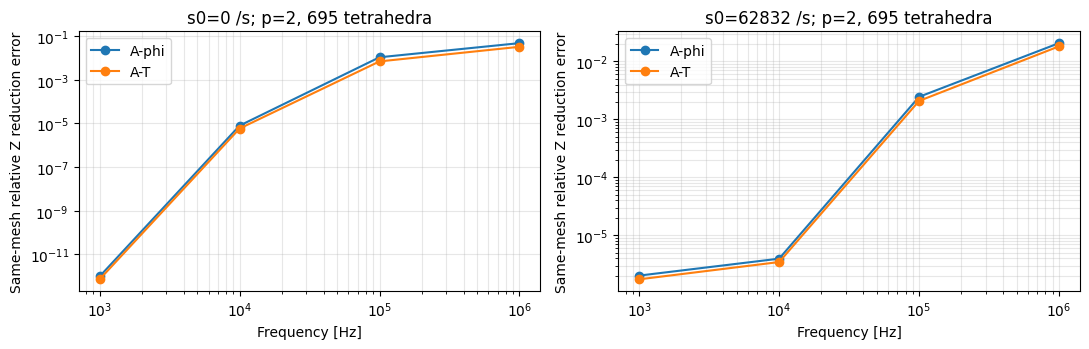

In [7]:
for c in cases:
    if c['mesh']['geometry']!='notched':continue
    for a,t in zip(c['runs'],c['A_T_runs']):
        va=np.column_stack([a['Rhat'],a['L']]).ravel();vt=np.column_stack([t['Rhat'],t['L']]).ravel()
        print(c['tag'],'s0',a['s0'],'R0 L1 R2 L3 R4 L5 R6 L7 gaps[%]:',100*abs(vt/va-1))
        print('full Z gaps:',[abs(complex(*f['full_Z'])/complex(*g['full_Z'])-1) for f,g in zip(t['frequency'],a['frequency'])])
plot=tags['notched_p2_base'];m=plot['mesh'];fig,axes=plt.subplots(1,2,figsize=(11,3.6))
for i,axis in enumerate(axes):
    for name,group in [('A-phi',plot['runs']),('A-T',plot['A_T_runs'])]:
        fs=group[i]['frequency'];axis.loglog([f['hz'] for f in fs],[f['reduction_error'] for f in fs],'o-',label=name)
    axis.set_title(f"s0={plot['runs'][i]['s0']:.0f} /s; p={m['order']}, {m['ne']} tetrahedra")
    axis.set_xlabel('Frequency [Hz]');axis.set_ylabel('Same-mesh relative Z reduction error');axis.grid(True,which='both',alpha=.3);axis.legend()
fig.tight_layout();plt.show()

### Stage depth and frequency scope

The following table uses the named notched p2 base mesh. It tests only 2/4/6/8-element prefixes against the same full FE solution at sampled frequencies. A 1% threshold here is a **reduction** threshold, separate from oracle/FE error. “Not reached” is retained when eight elements miss it. No unsampled-band guarantee, no universal depth and no high-frequency continuum accuracy claim follow from these results. The skin-depth screen uses actual conductor chord sizes; air refinement cannot resolve a conducting skin layer.

In [8]:
print('Stage table mesh:',plot['tag'],m['region_element_counts'],m['region_max_chord_m'])
for name,group in [('A-phi',plot['runs']),('A-T',plot['A_T_runs'])]:
    for r in group:
        R=np.array(r['R_phys']);L=np.array(r['L_phys']);b=np.array(r['port'])
        errors=np.array([[abs((1/(b[:k]@np.linalg.solve(R[:k,:k]+2j*np.pi*f['hz']*L[:k,:k],b[:k])))/complex(*f['full_Z'])-1) for f in r['frequency']] for k in range(1,5)])
        band=np.maximum.accumulate(errors,axis=1)
        print(name,'s0',r['s0'],'minimum elements for sampled-band error<=1%:',
              [2*(np.flatnonzero(band[:,j]<=.01)[0]+1) if np.any(band[:,j]<=.01) else 'not reached' for j in range(4)])
        print('prefix errors:',errors)
print('Skin screens on all meshes:')
for c in cases:print(c['tag'],[(f['hz'],f['mesh_resolution_screen']) for f in c['runs'][0]['frequency']])

Stage table mesh: notched_p2_base {'conductor': 136, 'air': 559} {'conductor': 0.012, 'air': 0.012}
A-phi s0 0.0 minimum elements for sampled-band error<=1%: [np.int64(2), np.int64(4), 'not reached', 'not reached']
prefix errors: [[4.51692020e-03 1.00691003e-01 2.94720561e-01 4.22435614e-01]
 [1.50836056e-06 2.72322955e-03 6.67805743e-02 1.41115822e-01]
 [7.14655621e-10 9.02383267e-05 2.21078573e-02 7.16287737e-02]
 [9.76067544e-13 7.94003338e-06 1.08236444e-02 4.81157417e-02]]
A-phi s0 62831.853071795864 minimum elements for sampled-band error<=1%: [np.int64(4), np.int64(4), np.int64(6), 'not reached']
prefix errors: [[1.87463711e-01 8.39072519e-02 1.50254321e-01 2.44591194e-01]
 [5.93930598e-03 4.59209858e-03 4.08477464e-02 9.72355666e-02]
 [5.66805822e-05 7.19458761e-05 7.88353200e-03 3.82431735e-02]
 [2.02013429e-06 3.95771166e-06 2.45159583e-03 2.07100962e-02]]
A-T s0 0.0 minimum elements for sampled-band error<=1%: [np.int64(2), np.int64(4), np.int64(8), 'not reached']
prefix err

## Reproduction and limits

```text
wolframscript -file mathematica/derive_coax_enclosure.wls docs/data/general_3d_air_oracle.json
python validation/cln3d/general_shape_air_environment.py --output docs/data/general_3d_air_environment.json
python validation/cln3d/coax_field_oracle.py --output docs/data/general_3d_air_fields.json
python validation/cln3d/general_shape_air_feasible_study.py --output docs/data/general_3d_air.json --export docs/data/general_3d_air_matrices.json
python validation/cln3d/general_shape_air_shell.py --study docs/data/general_3d_air.json --output docs/data/general_3d_air_shell.json
python validation/validate_general_3d_air.py
```

Native scripts require NGSolve/Netgen, scipy, numpy and mpmath. Notebook execution additionally needs matplotlib, nbformat, nbclient and ipykernel. CI uses numpy/stdlib for original small-matrix recomputation and stored evidence; it does not rerun refined native FEM. Source identities guard the producer, stages are independent coefficient copies, and incomplete runs are not accepted.

This experiment does not implement a finite-resistance return, open-space radiation, multiply connected conductors, nonlinear material, T–Omega air cuts, multiport coupling or extra surface modes. Under-resolved results remain same-mesh comparisons. Geometry and coarse discretization errors remain visible, and deep cross-form agreement is not claimed.

References: [NGSolve global-air magnetostatics and conductor scalar spaces](https://ngsolve.org/ngsolve/docs/i-tutorials/wta/coil.html), [NIST modified Bessel definitions](https://dlmf.nist.gov/10.25), [author paper on magnetic scalar-potential cuts](https://arxiv.org/abs/1902.01124). The gauge regularizer used in the NGSolve tutorial is not copied here. CLN method background: Kameari et al., IEEE Transactions on Magnetics 54(3), 7201804 (2018), [DOI](https://doi.org/10.1109/TMAG.2017.2743224); Kuriyama et al., 55(6), 7203404 (2019), [DOI](https://doi.org/10.1109/TMAG.2019.2900766). These references motivate methods, not this numerical example.